# Benchmark Data Analysis

This notebook analyzes the verification benchmark data from `data.json` and calculates median values for:
- `duration_ms`: Total verification duration in milliseconds
- `user_time_secs`: User CPU time in seconds
- `system_time_secs`: System CPU time in seconds

## 1. Load and Parse JSON Data

In [27]:
import json
import statistics
import os

# Path to the data.json file
tpcc_data_file = './tpcc_out/61920/data.json'
social_data_file = './social_out/data.json'
rubis_data_file = './rubis_out/data.json'

# Load the JSON data
with open(tpcc_data_file, 'r') as f:
    tpcc_data = json.load(f)
with open(social_data_file, 'r') as f:
    social_data = json.load(f)
with open(rubis_data_file, 'r') as f:
    rubis_data = json.load(f)

print(f"Loaded data from: {tpcc_data_file, social_data_file, rubis_data_file}")
print(f"Input file: {tpcc_data['input_file'], social_data['input_file'], rubis_data['input_file']}")
print(f"Total verifications: {tpcc_data['summary']['verification_total'], social_data['summary']['verification_total'], rubis_data['summary']['verification_total']}")

Loaded data from: ('./tpcc_out/61920/data.json', './social_out/data.json', './rubis_out/data.json')
Input file: ('tpcc.transact', 'social.transact', 'rubis.transact')
Total verifications: (284, 128, 91)


## 2. Extract Duration

In [ ]:
# Extract metrics from all verifications
tpcc_duration_ms_values = []
social_duration_ms_values = []
rubis_duration_ms_values = []

def extract_metrics(data, duration_ms_values):
    for verification in data['c_edge_verifications']:
        # Extract duration_ms (always present)
        duration_ms_values.append(verification['duration_ms'])

extract_metrics(tpcc_data, tpcc_duration_ms_values)
extract_metrics(social_data, social_duration_ms_values)
extract_metrics(rubis_data, rubis_duration_ms_values)


# Group datasets and their titles for easier processing
datasets = {
    "TPCC": tpcc_duration_ms_values,
    "Social": social_duration_ms_values,
    "RUBiS": rubis_duration_ms_values,
}

## 3. Visualize Distribution

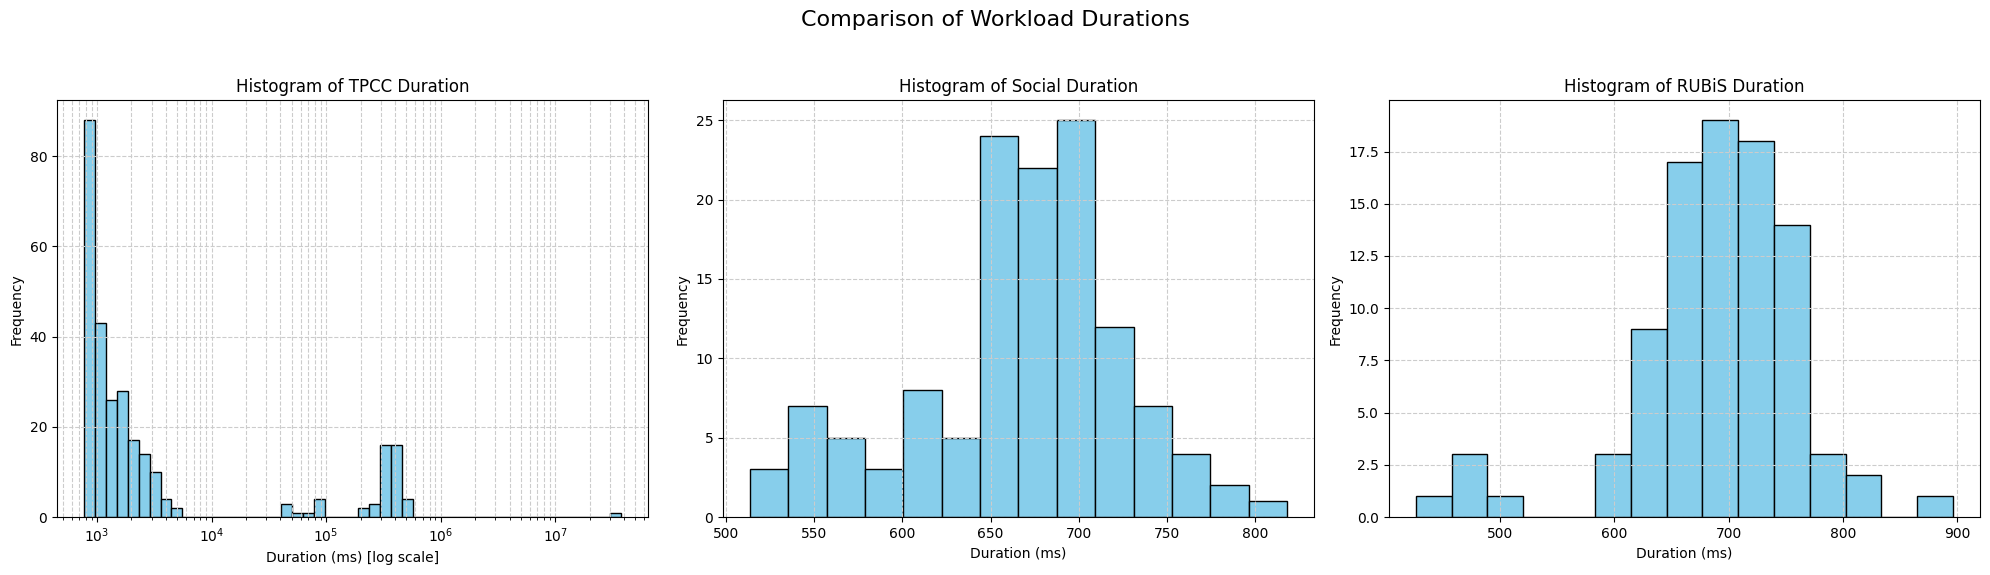

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration Options ---
# Option to change the color theme easily
color_theme = {
    "facecolor": "skyblue",
    "edgecolor": "black",
    "gridcolor": "#cccccc",
    "linestyle": "--"
}

# --- Plotting Function (now more flexible) ---
def create_histogram(ax, data, title, color_theme, use_log_scale=True):
    """Creates a histogram on a given matplotlib axis with an option for log scale."""
    if data is None or len(data) == 0:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
        ax.set_title(title)
        return

    # Conditionally determine bins and scale based on the user's choice
    if use_log_scale:
        # Define bins on a log scale for a log-scaled plot
        min_val = np.min(data)
        max_val = np.max(data)
        # Ensure min_val is positive for log scale
        if min_val <= 0:
            min_val = 1
        bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)
        xlabel = 'Duration (ms) [log scale]'
    else:
        # For a linear scale, 'auto' is a robust choice for binning
        bins = 'auto'
        xlabel = 'Duration (ms)'

    # Create the histogram
    ax.hist(data, bins=bins, color=color_theme["facecolor"], edgecolor=color_theme["edgecolor"])

    # Set the x-axis scale based on the option
    if use_log_scale:
        ax.set_xscale('log')
    else:
        ax.set_xscale('linear')

    # Add titles and labels for clarity
    ax.set_title(f'Histogram of {title} Duration')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Frequency')
    ax.grid(True, which="both", ls=color_theme["linestyle"], color=color_theme["gridcolor"])


# --- Main Execution ---
# 1. Create the combined figure with three subplots in one row
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Comparison of Workload Durations', fontsize=16)

create_histogram(axes[0], datasets["TPCC"], "TPCC", color_theme, use_log_scale=True)
create_histogram(axes[1], datasets["Social"], "Social", color_theme, use_log_scale=False)
create_histogram(axes[2], datasets["RUBiS"], "RUBiS", color_theme, use_log_scale=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

## 4. Save figures

In [31]:
# Directory to save the figures
output_dir = "histogram_figures_out"
os.makedirs(output_dir, exist_ok=True) # Create the directory if it doesn't exist

print(f"Saving individual plots to '{output_dir}/' directory...")
for name, data in datasets.items():
    # Create a new, single figure for saving
    individual_fig, individual_ax = plt.subplots(figsize=(10, 6))
    
    # Plot the data on this new figure
    create_histogram(individual_ax, data, name, color_theme, use_log_scale=(name == "TPCC"))
    
    # Define the output path and save the figure
    file_path = os.path.join(output_dir, f"{name.lower()}_histogram.png")
    individual_fig.savefig(file_path, dpi=150, bbox_inches='tight')
    
    # Close the figure to free up memory
    plt.close(individual_fig)


Saving individual plots to 'histogram_figures_out/' directory...
